In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from scipy.stats import chi2_contingency, levene
from statsmodels.formula.api import ols
!pip install pingouin
import pingouin as pg
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.4 MB/s eta 0:00:00


# Exploración para Análisis

In [ ]:
df_final=pd.read_csv('df_final.csv',encoding='latin-1')
print(tabulate(df_final.head(2), headers='keys', tablefmt='psql'))

+----+----------------------+--------+-------------------+--------------------------------------------------------+-----------------------------------------------------------------------------------------------------+--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+----------------+-------------------+------------------+--------------------+----------------+------------------+--------------------+--------+----------+---------+------------------------+-----------------------+-----------+
|    | Comunidad Autonoma   | Sexo   | Pais              | Estudios                                               | Clase                                                                                               |   Edad |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |   Alcohol_cant | Salud_Percibida   |   Cronicidad_bin |   Hipertension_bin |   Di

In [ ]:
print(tabulate(df_final.describe().T, headers='keys', tablefmt='psql'))

+---------------------+---------+-------------+-----------+----------+--------+----------+----------+----------+
|                     |   count |        mean |       std |      min |    25% |      50% |      75% |      max |
|---------------------+---------+-------------+-----------+----------+--------+----------+----------+----------|
| Edad                |   21010 |  54.4896    | 19.1419   |  15      |  40    |  55      |  69      | 103      |
| Carne_frec          |   20917 |   3.83896   |  2.55344  |   0      |   1.5  |   3      |   5      |  10      |
| Lacteos_frec        |   20917 |   7.8965    |  3.24428  |   0      |   5    |  10      |  10      |  10      |
| Pescado_frec        |   20909 |   2.15429   |  1.59057  |   0      |   1.5  |   1.5    |   3      |  10      |
| Fruta_frec          |   20915 |   7.0076    |  3.5321   |   0      |   3    |  10      |  10      |  10      |
| Embutidos_frec      |   20899 |   2.6163    |  2.51432  |   0      |   0.5  |   1.5    |   3  

Se puede ver que todas las variables escogidas para el estudio estan dentro del los rangos que se especificaron en la limpieza de los datos.

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21010 entries, 0 to 21009
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Comunidad Autonoma    21010 non-null  object 
 1   Sexo                  21010 non-null  object 
 2   Pais                  21010 non-null  object 
 3   Estudios              21010 non-null  object 
 4   Clase                 21010 non-null  object 
 5   Edad                  21010 non-null  int64  
 6   Carne_frec            20917 non-null  float64
 7   Lacteos_frec          20917 non-null  float64
 8   Pescado_frec          20909 non-null  float64
 9   Fruta_frec            20915 non-null  float64
 10  Embutidos_frec        20899 non-null  float64
 11  Verduras_frec         20911 non-null  float64
 12  Refrescos_frec        20893 non-null  float64
 13  Alcohol_cant          20959 non-null  float64
 14  Salud_Percibida       21010 non-null  object 
 15  Cronicidad_bin     

In [ ]:
# Se revisa la distribución de la variable objetivo para obtener el porcentaje de cada categoría
print(tabulate(df_final["Salud_Percibida"].value_counts(normalize=True).to_frame()*100, headers='keys', tablefmt='psql'))

+-------------------+--------------+
| Salud_Percibida   |   proportion |
|-------------------+--------------|
| Bueno             |     48.5245  |
| Regular           |     24.1409  |
| Muy bueno         |     18.5531  |
| Malo              |      7.01571 |
| Muy malo          |      1.76583 |
+-------------------+--------------+


Se separan variables categoricas de numéricas

In [ ]:
# Se eligen las variables categoricas del dataset para hacer un bucle de interpretacion de todas las variables

var_cat= ['Cronicidad_bin',
          'Hipertension_bin','Diabetes_bin','Colesterol_bin',
          'Actividad_física_cat', 'IMC_cat', 'Comunidad Autonoma','Sexo',
          'Pais','Estudios',
          'Clase']

In [ ]:
# Se eligen las variables numéricas del conjunto de datos para hacer un bucle de interpretacion de todas las variables
var_num=df_final.columns.tolist()
var_num= [col for col in var_num if col not in var_cat]
var_num.remove('Salud_Percibida')
print(var_num)

['Edad', 'Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec', 'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Alcohol_cant', 'Comorbilidad_num', 'Peso', 'Altura', 'IMC', 'Sedentarismo%_horas']


# Estadistica descriptiva e inferencial

# Descriptiva

**Descriptiva principales Variables categoricas**

In [ ]:
# Revisión de la Salud Percibida Vs. Sexo

salud_sexo= pd.crosstab(df_final["Salud_Percibida"],df_final["Sexo"],normalize="index")
salud_sexo= (salud_sexo*100).round(2)
print(salud_sexo.to_string())


Sexo             Hombre  Mujer
Salud_Percibida               
Bueno             48.57  51.43
Malo              34.74  65.26
Muy bueno         53.16  46.84
Muy malo          32.35  67.65
Regular           39.69  60.31


Los resultados describen que las mujeres declaran peor salud con mas frecuencia, siendo en la categoria Muy mala salud, el 67.65% de las mujeres, mala salud, el 65.26% y regular el 60.31. Los hombres tienen tendencia a reportar mejor salud.


In [ ]:
# Revisión de la variable objetivo Vs. Clase

salud_clase= pd.crosstab(df_final["Cronicidad_bin"],df_final["Clase"],normalize="index")
salud_clase= (salud_clase*100).round(2)
print(tabulate(salud_clase.T, headers='keys', tablefmt='psql'))


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+-------+
| Clase                                                                                                                                                                                                                     |   0.0 |   1.0 |
|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+-------|
| Directores/as y gerentes de establecimientos de 10 o más asalariados/as y profesionales tradicionalmente asociados/as a las licenciaturas universitarias                                                                  | 13.43 | 11.4  |
| Directores/as y gerentes de establecimientos d

In [ ]:
# Variables de consumo (frecuencia)

var_frecuencia= [c for c in var_num if "_frec" in c]
print(var_frecuencia)

['Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec', 'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec']


In [ ]:
print(tabulate(df_final.groupby("Cronicidad_bin")[var_frecuencia].mean().round(2), headers='keys', tablefmt='psql'))

+------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
|   Cronicidad_bin |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
|                0 |         3.94 |           7.74 |           2.09 |         6.66 |             2.85 |            5.31 |             1.42 |
|                1 |         3.77 |           8    |           2.19 |         7.21 |             2.47 |            5.89 |             0.96 |
+------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+


In [ ]:
print(tabulate(df_final.groupby("Sexo")[var_frecuencia].mean().round(2), headers='keys', tablefmt='psql'))

+--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
| Sexo   |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
| Hombre |         4.01 |           7.79 |            2.1 |         6.72 |             2.97 |            5.21 |             1.33 |
| Mujer  |         3.69 |           7.98 |            2.2 |         7.25 |             2.32 |            6.08 |             0.96 |
+--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+


In [ ]:
groupo_frec= df_final.groupby("Comunidad Autonoma")[var_frecuencia].mean().round(2)
org_frec = groupo_frec.sort_values(by='Lacteos_frec', ascending=False)
print(tabulate(org_frec, headers='keys', tablefmt='psql'))

+-----------------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+
| Comunidad Autonoma          |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |
|-----------------------------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------|
| País Vasco                  |         3.56 |           8.94 |           2.2  |         7.19 |             2.21 |            5.57 |             0.96 |
| Extremadura                 |         3.62 |           8.93 |           1.92 |         7.32 |             2.41 |            4.42 |             1.07 |
| Ceuta                       |         3.75 |           8.77 |           3.08 |         7.85 |             2.68 |            7.31 |             1.24 |
| Castilla y León             |         4.51 |           8.65 |           2.42 |        

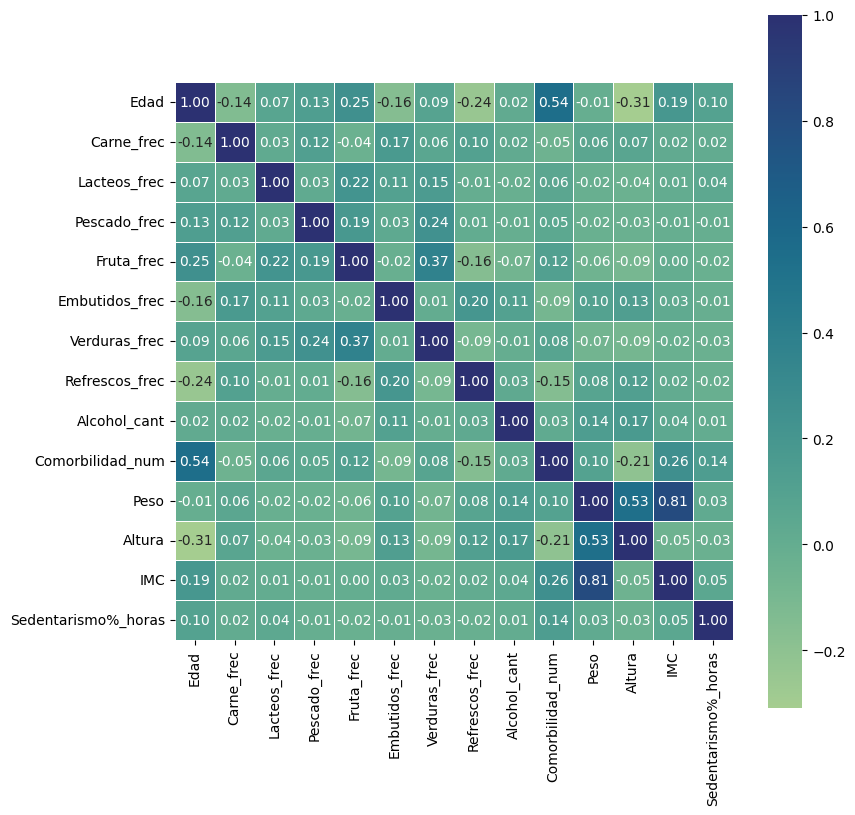

In [ ]:
df_corr = df_final[var_num].corr()
plt.figure(figsize=(9,9))
sns.heatmap(df_corr, annot=True, cmap='crest', fmt=".2f", square= True, cbar=True, linewidths=0.7)
plt.show()

# Inferencial

**Inferencial Variables categoricas**

In [ ]:
# Se toma como referencia https://www.geeksforgeeks.org/python/python-pearsons-chi-square-test/
sal_sexo_contingencia= pd.crosstab(df_final["Salud_Percibida"],df_final["Sexo"], margins = False)
stat, p, dof, expected= chi2_contingency(sal_sexo_contingencia)

# Interpretacion automática de p-value
alpha = 0.05
print("Valor p es " + str(p))
if p <= alpha:
    print('Variables dependientes, rechazar hipotesis nula')
else:
    print('Variables independientes, aceptar hipótesis nula')


Valor p es 5.831579883584417e-62
Variables dependientes, rechazar hipotesis nula


Este resultado nos indica que esta variable puede ser relevante para agregar en el modelamiento. Se hara la misma revision con todas las variables categoricas.

In [ ]:
for var in var_cat:
  tabla_cat= pd.crosstab(df_final["Salud_Percibida"],df_final[var])
  stat, p, dof, expected= chi2_contingency(tabla_cat)

  # Interpretacion automática de p-value
  alpha = 0.05
  print(f"Valor p para {var} " + str(p))
  if p <= alpha:
      print('Variables dependientes, rechazar hipotesis nula\n')
  else:
      print('Variables independientes, aceptar hipótesis nula\n')


Valor p para Cronicidad_bin 0.0
Variables dependientes, rechazar hipotesis nula

Valor p para Hipertension_bin 0.0
Variables dependientes, rechazar hipotesis nula

Valor p para Diabetes_bin 7.0490946625398975e-205
Variables dependientes, rechazar hipotesis nula

Valor p para Colesterol_bin 0.0
Variables dependientes, rechazar hipotesis nula

Valor p para Actividad_física_cat 0.0
Variables dependientes, rechazar hipotesis nula

Valor p para IMC_cat 8.416217584294842e-133
Variables dependientes, rechazar hipotesis nula

Valor p para Comunidad Autonoma 2.757459629332967e-69
Variables dependientes, rechazar hipotesis nula

Valor p para Sexo 5.831579883584417e-62
Variables dependientes, rechazar hipotesis nula

Valor p para Pais 6.342910332199225e-17
Variables dependientes, rechazar hipotesis nula

Valor p para Estudios 0.0
Variables dependientes, rechazar hipotesis nula

Valor p para Clase 5.997746525311632e-58
Variables dependientes, rechazar hipotesis nula



**Inferencial variables numéricas**

Como el tamaño del conjunto de datos es mayor a 20.000 registros, se aplica el teorema del limite central que establece que la distribución del estimador de la media es aproximadamente normal, por lo que no se compruba normalidad. Sin embargo, se revisara si hay homocedasticidad para asegurar que se usa apropiadamente el anova unifactorial traicional o si se requeire otro metodo.

Levene test

In [ ]:
# Se toma como referencia esta fuente https://www.geeksforgeeks.org/engineering-mathematics/levenes-test/

for var in var_num:
  conjunto=[grupo[var].dropna() for name, grupo in df_final.groupby("Salud_Percibida")]
  stat, p_levene= levene(*conjunto, center='mean')

  # Interpretacion automática de p-value
  alpha= 0.05

  if p_levene >= alpha:
    print(f"Varianzas iguales. Usar ANOVA para {var}\n")
  else:
    print(f"Varianzas distintas. Usar otra prueba para {var}\n")

Varianzas distintas. Usar otra prueba para Edad

Varianzas distintas. Usar otra prueba para Carne_frec

Varianzas distintas. Usar otra prueba para Lacteos_frec

Varianzas distintas. Usar otra prueba para Pescado_frec

Varianzas distintas. Usar otra prueba para Fruta_frec

Varianzas iguales. Usar ANOVA para Embutidos_frec

Varianzas distintas. Usar otra prueba para Verduras_frec

Varianzas distintas. Usar otra prueba para Refrescos_frec

Varianzas distintas. Usar otra prueba para Alcohol_cant

Varianzas distintas. Usar otra prueba para Comorbilidad_num

Varianzas distintas. Usar otra prueba para Peso

Varianzas iguales. Usar ANOVA para Altura

Varianzas distintas. Usar otra prueba para IMC

Varianzas distintas. Usar otra prueba para Sedentarismo%_horas



In [ ]:
df_final.columns

Index(['Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec',
       'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Alcohol_cant',
       'Salud_Percibida', 'Cronicidad_bin', 'Hipertension_bin', 'Diabetes_bin',
       'Colesterol_bin', 'Comorbilidad_num', 'Actividad_física_cat',
       'Sedentarismo%_horas', 'IMC_cat', 'Comunidad Autonoma', 'Sexo', 'Pais',
       'Estudios', 'Edad', 'Clase'],
      dtype='object')

Se aplica el anova tradicional para la variable que aplica y Welch, pues no cumplen con el requisito de homocedasticidad.

In [ ]:
anova= ols('Q("Embutidos_frec") ~ C(Q("Salud_Percibida"))', data=df_final.drop).fit()
anova_table= sm.stats.anova_lm(anova, typ=2)
print(anova_table)

El valor p de esta variable es muy pequeño por lo que se concluye que esta estadisticamente asociada, aunque no es causalidad. Para las demas variables se hara un bucle con la prueba ANOVA Welch

In [ ]:
# Se toma como referencia este codigo https://www.geeksforgeeks.org/machine-learning/how-to-perform-welchs-anova-in-python/
# Referencia: https://www.statology.org/welchs-anova-in-python/

var_no = "Embutidos_frec"
var_welch = [col for col in var_num if col != var_no]


for col in var_welch:
    try:
      res= pg.welch_anova(dv=col, between='Salud_Percibida', data=df_final)
      p_welch= res['p-unc'][0]
      if p_welch <= 0.05:
       print(f"Significancia estadistica para {col}: con p-valor = {p_welch:.6e} ")
      else:
        print(f"No hay significancia estadistica para {col}: con p-valor = {p_welch:.6e} ")
    except Exception as e:
      print(f"Error en {col}: {e}")


Significancia estadistica para Carne_frec: con p-valor = 6.004867e-18 
Significancia estadistica para Lacteos_frec: con p-valor = 3.505336e-04 
Significancia estadistica para Pescado_frec: con p-valor = 3.198985e-02 
Significancia estadistica para Fruta_frec: con p-valor = 2.395591e-20 
Significancia estadistica para Verduras_frec: con p-valor = 1.554240e-12 
Significancia estadistica para Refrescos_frec: con p-valor = 3.868696e-27 
Significancia estadistica para Alcohol_cant: con p-valor = 1.326122e-14 
Significancia estadistica para Comorbilidad_num: con p-valor = 0.000000e+00 
Significancia estadistica para Sedentarismo%_horas: con p-valor = 1.011817e-84 
Significancia estadistica para Edad: con p-valor = 0.000000e+00 
